# 轨迹预处理与特征提取

## 一、环境配置与数据加载

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据集根目录
data_root = '../data/raw/ATC/'

### 1.1 加载完整数据集

In [2]:
def load_full_atc_dataset(data_root):
    """
    加载ATC完整数据集，保留所有原始字段
    列定义: frame, person_id, pos_x, pos_y, pos_z, velocity, motion_angle, facing_angle
    单位: 坐标mm, 速度mm/s, 角度rad
    """
    all_trajectory_df = []
    all_metadata = []
    
    for day_idx in range(1, 7):
        day_folder = f'ATC-{day_idx}'
        day_path = os.path.join(data_root, day_folder)
        
        if not os.path.exists(day_path):
            continue
            
        for filename in os.listdir(day_path):
            if not filename.endswith('.csv'):
                continue
                
            file_path = os.path.join(day_path, filename)
            df = pd.read_csv(file_path, header=None)
            
            # 按官方说明为列名赋相应值
            df.columns = [
                'frame', 'person_id', 
                'pos_x', 'pos_y', 'pos_z',
                'velocity', 'motion_angle', 'facing_angle'
            ]
            
            # 按行人和帧号排序
            df = df.sort_values(['person_id', 'frame']).reset_index(drop=True)
            
            # 按行人ID拆分单条轨迹
            for pid, group in df.groupby('person_id'):
                if len(group) >= 15:  # 过滤过短轨迹
                    all_trajectory_df.append(group.reset_index(drop=True))
                    all_metadata.append({
                        'day': day_idx,
                        'person_id': pid,
                        'length': len(group),
                        'source_file': filename
                    })
    
    return all_trajectory_df, all_metadata

# 加载数据
traj_dfs, metadata = load_full_atc_dataset(data_root)
print(f"成功加载 {len(traj_dfs)} 条有效完整轨迹")
print(f"单条轨迹字段: {list(traj_dfs[0].columns)}")

成功加载 87365 条有效完整轨迹
单条轨迹字段: ['frame', 'person_id', 'pos_x', 'pos_y', 'pos_z', 'velocity', 'motion_angle', 'facing_angle']


## 二、轨迹预处理

### 2.1 数据清洗与异常点过滤

In [3]:
def clean_trajectory(df):
    """清洗单条轨迹：去除速度突变、坐标跳变的异常点"""
    df = df.copy()
    
    # 前置校验：轨迹本身过短直接返回空
    if len(df) < 2:
        return df.iloc[0:0]  # 返回空DataFrame，保持列结构一致
    
    # 1. 去除速度为负或异常大的点
    df = df[(df['velocity'] >= 0) & (df['velocity'] < 3000)]  # 3m/s以内为正常行人速度
    if len(df) < 2:
        return df.iloc[0:0]
    
    # 2. 去除坐标跳变点（相邻帧位移超过500mm）
    dx = df['pos_x'].diff().abs()
    dy = df['pos_y'].diff().abs()
    # 用 fillna(True) 自动保留第一点
    jump_mask = ((dx < 500) & (dy < 500)).fillna(True)
    df = df[jump_mask]
    if len(df) < 2:
        return df.iloc[0:0]
    
    # 3. 去除高度异常点
    df = df[(df['pos_z'] > 1000) & (df['pos_z'] < 2000)]  # 行人高度1m-2m
    
    return df.reset_index(drop=True)


# 批量清洗所有轨迹
cleaned_traj = []
for traj in traj_dfs:
    cleaned = clean_trajectory(traj)
    # 清洗后仍有足够长度才保留
    if len(cleaned) >= 10:
        cleaned_traj.append(cleaned)

print(f"清洗后剩余有效轨迹: {len(cleaned_traj)} 条")

清洗后剩余有效轨迹: 83469 条


### 2.2 轨迹平滑处理

In [4]:
def smooth_trajectory(df, window_size=3):
    """滑动窗口平滑轨迹的坐标、速度、角度序列"""
    df = df.copy()
    
    # 坐标平滑
    df['pos_x_smooth'] = df['pos_x'].rolling(window=window_size, center=True).mean()
    df['pos_y_smooth'] = df['pos_y'].rolling(window=window_size, center=True).mean()
    
    # 速度平滑
    df['velocity_smooth'] = df['velocity'].rolling(window=window_size, center=True).mean()
    
    # 角度平滑需要处理周期性，用向量平均法
    motion_cos = np.cos(df['motion_angle']).rolling(window=window_size, center=True).mean()
    motion_sin = np.sin(df['motion_angle']).rolling(window=window_size, center=True).mean()
    df['motion_angle_smooth'] = np.arctan2(motion_sin, motion_cos)
    
    facing_cos = np.cos(df['facing_angle']).rolling(window=window_size, center=True).mean()
    facing_sin = np.sin(df['facing_angle']).rolling(window=window_size, center=True).mean()
    df['facing_angle_smooth'] = np.arctan2(facing_sin, facing_cos)
    
    # 去除首尾NaN
    df = df.dropna().reset_index(drop=True)
    return df

# 批量平滑
smoothed_traj = [smooth_trajectory(traj) for traj in cleaned_traj]
print("轨迹平滑完成")

轨迹平滑完成


### 2.3 可视化对比平滑效果

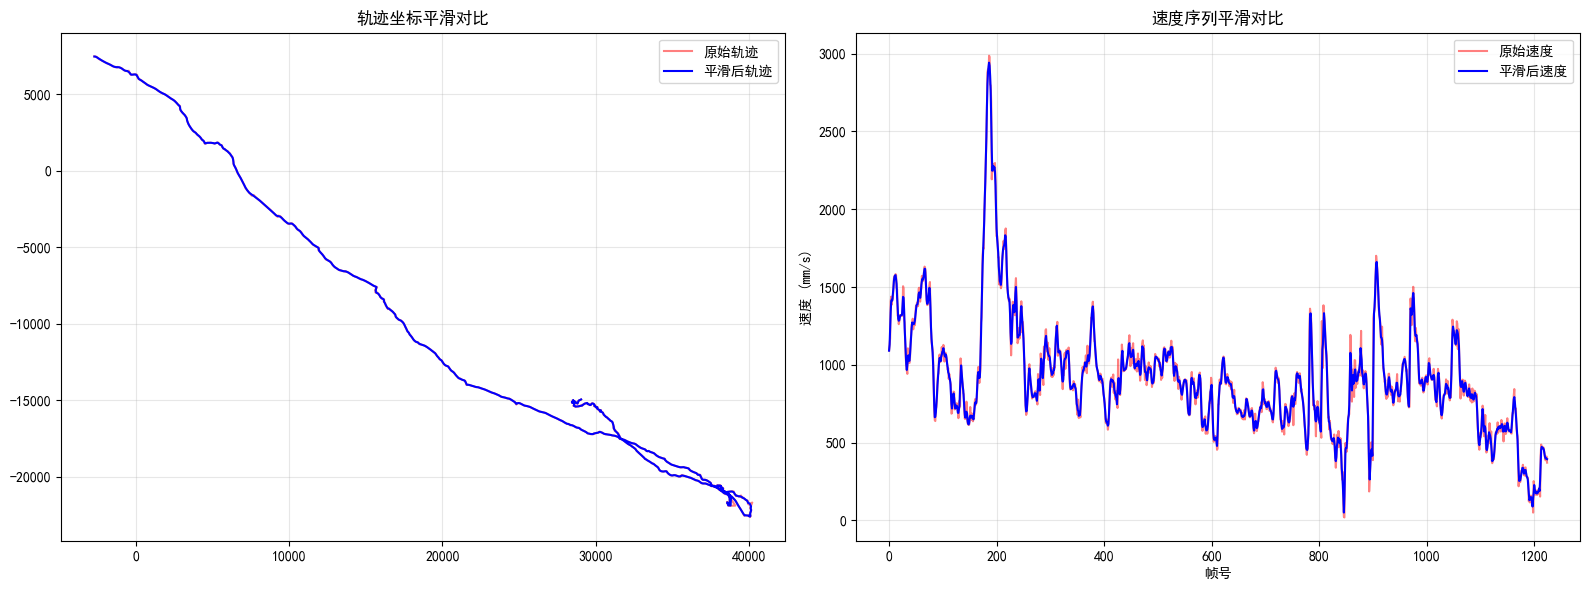

In [5]:
# 随机选一条轨迹对比平滑前后效果
idx = np.random.randint(0, len(smoothed_traj))
sample = smoothed_traj[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 坐标对比
axes[0].plot(sample['pos_x'], sample['pos_y'], 'r-', alpha=0.5, label='原始轨迹')
axes[0].plot(sample['pos_x_smooth'], sample['pos_y_smooth'], 'b-', label='平滑后轨迹')
axes[0].set_title('轨迹坐标平滑对比')
axes[0].legend()
axes[0].axis('equal')
axes[0].grid(alpha=0.3)

# 速度对比
axes[1].plot(sample['velocity'], 'r-', alpha=0.5, label='原始速度')
axes[1].plot(sample['velocity_smooth'], 'b-', label='平滑后速度')
axes[1].set_title('速度序列平滑对比')
axes[1].set_xlabel('帧号')
axes[1].set_ylabel('速度 (mm/s)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 三、多维度特征提取

### 3.1 角度差计算工具函数（处理周期性）

In [6]:
def angle_diff(angles):
    """计算角度序列的差分，处理0-2π跳变问题"""
    diff = np.diff(angles)
    # 将差值映射到 [-π, π] 区间
    diff = np.arctan2(np.sin(diff), np.cos(diff))
    return diff

### 3.2 单条轨迹特征提取函数

In [7]:
def extract_trajectory_features(df):
    """
    增强版轨迹特征提取：21维基础特征
    原有16维完全保留，新增：加速度2维 + 转向增强3维
    返回: 特征字典，完全向下兼容
    """
    # 提取序列数据
    v = df['velocity_smooth'].values
    motion_ang = df['motion_angle_smooth'].values
    facing_ang = df['facing_angle_smooth'].values
    x = df['pos_x_smooth'].values
    y = df['pos_y_smooth'].values
    
    n = len(df)
    if n < 5:
        return None
    
    # ========== 1. 速度特征（4维） ==========
    avg_speed = np.mean(v)
    max_speed = np.max(v)
    std_speed = np.std(v)
    speed_cv = std_speed / (avg_speed + 1e-6)
    
    # ========== 2. 运动方向变化特征（3维） ==========
    motion_diffs = angle_diff(motion_ang)
    avg_dir_change = np.mean(np.abs(motion_diffs))
    max_dir_change = np.max(np.abs(motion_diffs))
    std_dir_change = np.std(motion_diffs)
    
    # ========== 3. 朝向与运动方向偏差特征（2维） ==========
    facing_motion_diff = np.arctan2(
        np.sin(facing_ang - motion_ang), 
        np.cos(facing_ang - motion_ang)
    )
    avg_facing_deviation = np.mean(np.abs(facing_motion_diff))
    max_facing_deviation = np.max(np.abs(facing_motion_diff))
    
    # ========== 4. 轨迹形态特征（3维） ==========
    path_length = np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2))
    start_end_dist = np.sqrt((x[-1]-x[0])**2 + (y[-1]-y[0])**2)
    tortuosity = path_length / (start_end_dist + 1e-6)
    
    # ========== 5. 停留/时长特征（2维） ==========
    low_speed_ratio = np.sum(v < 300) / n
    duration = n
    
    # ========== 6. 空间位置特征（2维） ==========
    center_x = np.mean(x)
    center_y = np.mean(y)

    # ========== 7. 加速度特征（2维，本次新增） ==========
    acceleration = np.diff(v)  # 瞬时加速度序列
    max_acceleration = np.max(np.abs(acceleration))  # 最大加/减速度绝对值
    std_acceleration = np.std(acceleration)          # 加速度波动程度

    # ========== 8. 转向模式增强特征（3维，本次新增） ==========
    # 8.1 转向频率：单位帧数内的有效转向次数（方向变化>0.1rad记为一次有效转向）
    turn_threshold = 0.1
    valid_turns = np.sum(np.abs(motion_diffs) > turn_threshold)
    turn_frequency = valid_turns / n  # 每帧的转向次数

    # 8.2 方向信息熵：衡量方向分布的随机程度，熵越高方向越杂乱
    n_bins = 8  # 将0-2π划分为8个方向区间
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    angle_counts, _ = np.histogram(motion_ang, bins=bins)
    angle_probs = angle_counts / np.sum(angle_counts)
    # 处理概率为0的项，避免log(0)报错
    angle_probs = angle_probs[angle_probs > 0]
    angle_entropy = -np.sum(angle_probs * np.log2(angle_probs))

    # 8.3 方向反转率：相邻转向方向相反的比例，刻画来回折返特性
    turn_signs = np.sign(motion_diffs)
    turn_signs = turn_signs[turn_signs != 0]
    if len(turn_signs) < 2:
        direction_reversal_rate = 0.0
    else:
        reversal_count = np.sum(np.abs(np.diff(turn_signs)) > 1)
        direction_reversal_rate = reversal_count / (len(turn_signs) - 1)
    
    # 组装特征字典，原有顺序完全不变，新增特征统一追加在末尾
    features = {
        'avg_speed': avg_speed,
        'max_speed': max_speed,
        'std_speed': std_speed,
        'speed_cv': speed_cv,
        'avg_dir_change': avg_dir_change,
        'max_dir_change': max_dir_change,
        'std_dir_change': std_dir_change,
        'avg_facing_deviation': avg_facing_deviation,
        'max_facing_deviation': max_facing_deviation,
        'path_length': path_length,
        'start_end_dist': start_end_dist,
        'tortuosity': tortuosity,
        'low_speed_ratio': low_speed_ratio,
        'duration': duration,
        'center_x': center_x,
        'center_y': center_y,
        # 以下为本次新增特征
        'max_acceleration': max_acceleration,
        'std_acceleration': std_acceleration,
        'turn_frequency': turn_frequency,
        'angle_entropy': angle_entropy,
        'direction_reversal_rate': direction_reversal_rate
    }
    
    return features

### 3.3 批量提取所有轨迹特征

In [8]:
# 批量提取特征
feature_list = []
valid_indices = []

for i, traj in enumerate(smoothed_traj):
    feat = extract_trajectory_features(traj)
    if feat is not None:
        feature_list.append(feat)
        valid_indices.append(i)

# 转换为DataFrame
feature_df = pd.DataFrame(feature_list)
print(f"成功提取 {len(feature_df)} 条轨迹的特征")
print(f"特征维度: {feature_df.shape[1]} 维")
print("\n特征统计概览:")
display(feature_df.describe())

成功提取 83469 条轨迹的特征
特征维度: 21 维

特征统计概览:


,avg_speed,max_speed,std_speed,speed_cv,avg_dir_change,max_dir_change,std_dir_change,avg_facing_deviation,max_facing_deviation,path_length,...,tortuosity,low_speed_ratio,duration,center_x,center_y,max_acceleration,std_acceleration,turn_frequency,angle_entropy,direction_reversal_rate
count,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,8.346900e+04,...,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000,83469.000000
mean,923.651093,1660.384037,230.520130,0.263901,0.047424,1.030497,0.094780,0.079979,1.047578,3.768772e+04,...,5.948987,0.025163,851.831854,7574.681322,-6357.866824,243.991401,49.457380,0.083117,1.600796,0.209099
std,282.368344,461.179313,83.831186,0.100556,0.031698,0.986197,0.076907,0.063008,0.830511,4.086086e+04,...,55.691342,0.060001,1663.102275,22230.048558,9571.465894,101.567114,14.131220,0.086684,0.752477,0.037902
min,34.685417,85.833333,11.147749,0.004862,0.005458,0.010483,0.004985,0.012853,0.026440,1.816706e+01,...,1.000193,0.000000,8.000000,-40212.562500,-27145.708333,14.966667,2.877058,0.000000,-0.000000,0.000000
25%,714.268213,1352.466667,178.300567,0.190339,0.026799,0.289279,0.040176,0.045892,0.414698,1.009525e+04,...,1.105115,0.000000,194.000000,-9694.660207,-13752.592593,170.066667,40.887043,0.019481,1.018926,0.191721
50%,908.966667,1642.466667,218.825476,0.241383,0.035694,0.522994,0.062819,0.059572,0.787142,2.860440e+04,...,1.227041,0.000000,535.000000,8171.488838,-5632.536697,234.633333,47.322396,0.049889,1.449711,0.208202
75%,1096.032772,1953.433333,266.274932,0.322982,0.058422,1.735804,0.129926,0.090961,1.336703,5.342619e+04,...,2.215340,0.025424,1078.000000,24598.798261,1041.605263,305.566667,55.036837,0.124183,2.228942,0.224109
max,2888.841667,2995.966667,1006.121495,1.235243,0.976369,3.141577,1.281977,1.609703,3.141579,2.237351e+06,...,7332.870811,1.000000,112195.000000,47761.222222,21782.972222,841.133333,299.323566,0.923077,2.996299,0.833333


## 四、特征标准化与保存

### 4.1 特征标准化

In [9]:
# 初始化标准化器
scaler = StandardScaler()
# 拟合并转换特征
feature_matrix = scaler.fit_transform(feature_df.values)

print(f"标准化后特征矩阵形状: {feature_matrix.shape}")
print(f"标准化后各维度均值≈0，标准差≈1")

标准化后特征矩阵形状: (83469, 21)
标准化后各维度均值≈0，标准差≈1


### 4.2 保存处理结果

In [10]:
# 创建保存目录
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

# 保存特征矩阵和标准化器
np.save('../data/processed/feature_matrix.npy', feature_matrix)
np.save('../data/processed/feature_names.npy', feature_df.columns.values)
import joblib
joblib.dump(scaler, '../data/processed/feature_scaler.pkl')

# 保存清洗后的轨迹数据（留作后续可视化）
joblib.dump(smoothed_traj, '../data/processed/smoothed_trajectories.pkl')

print("所有预处理结果已保存到 data/processed/ 目录")

所有预处理结果已保存到 data/processed/ 目录


## 五、特征可视化分析

### 5.1 单特征分布直方图

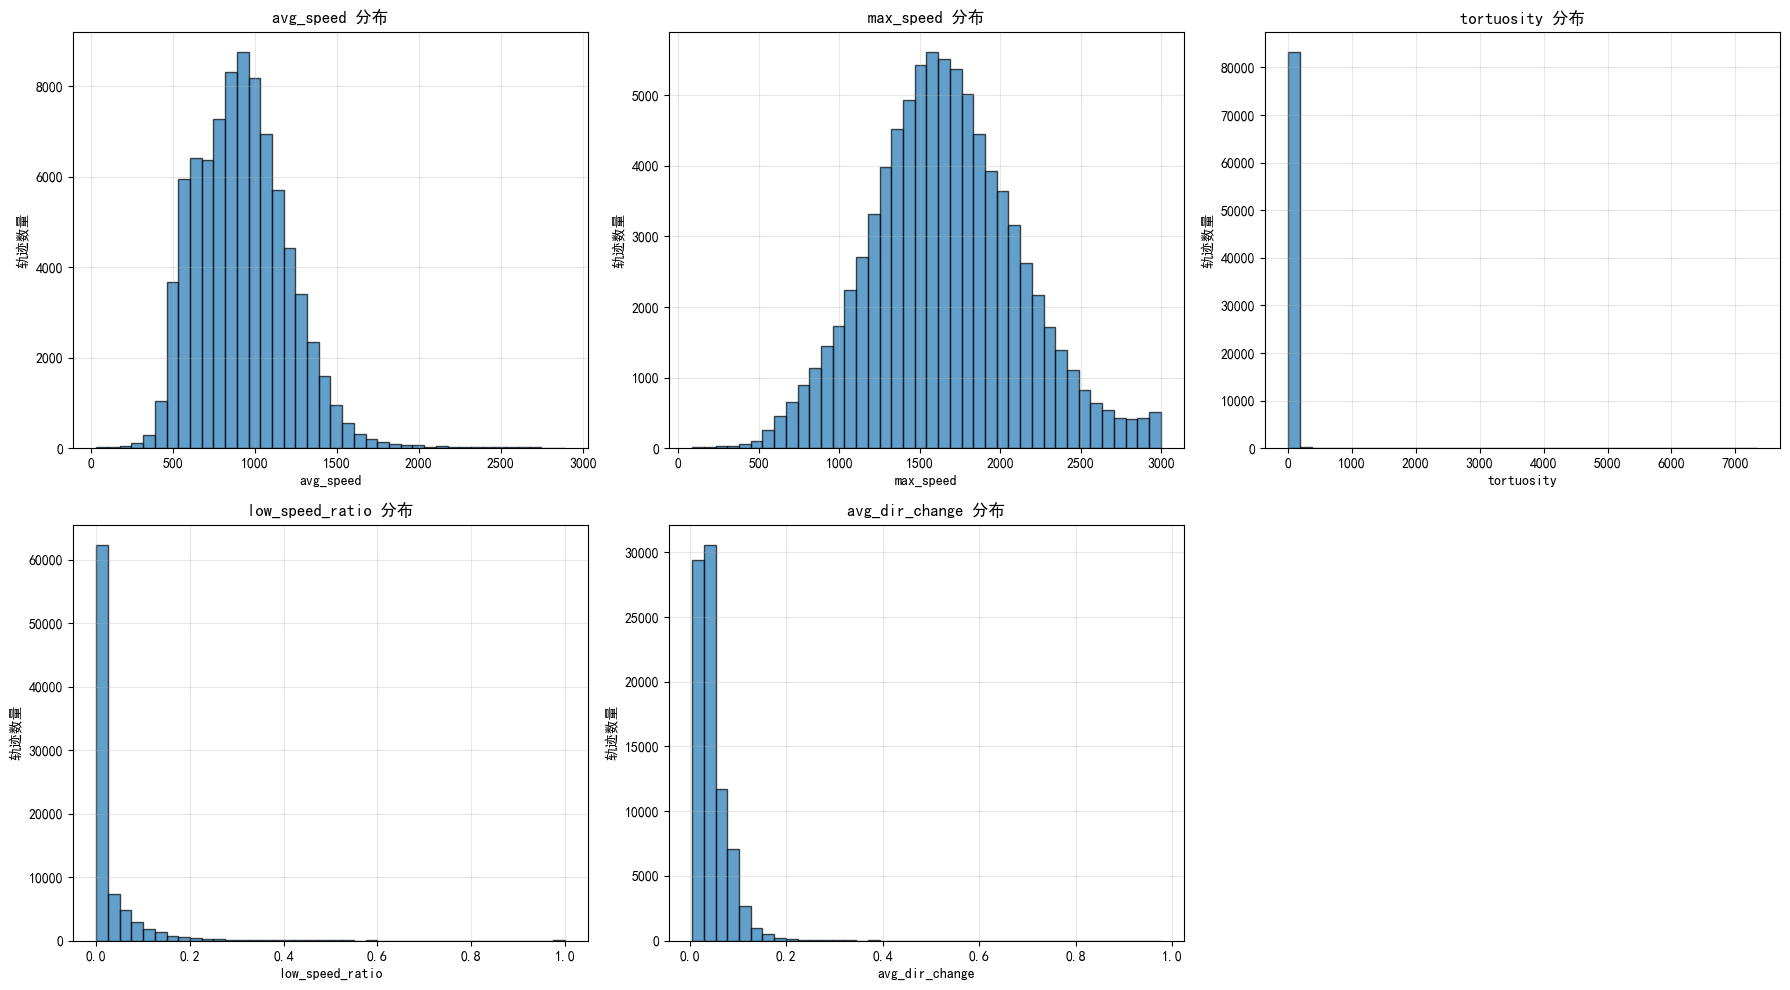

In [11]:
# 选取核心特征绘制分布
key_features = ['avg_speed', 'max_speed', 'tortuosity', 'low_speed_ratio', 'avg_dir_change']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].hist(feature_df[feat], bins=40, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feat} 分布')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('轨迹数量')
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('../results/figures/feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 PCA 降维可视化（查看数据聚集性）

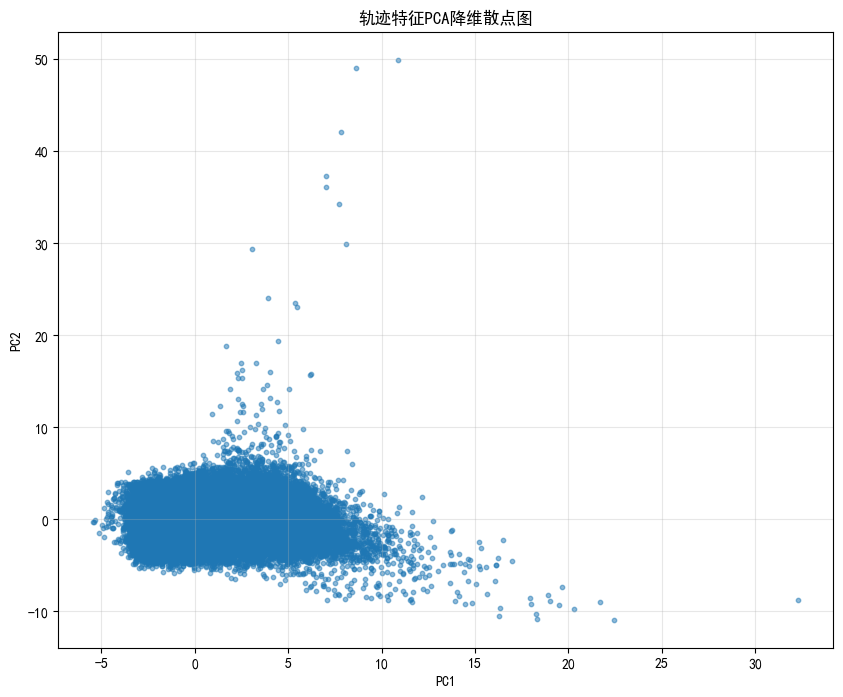

前两个主成分解释方差占比: 48.06%


In [12]:
from sklearn.decomposition import PCA

# 降维到2维用于可视化
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(feature_matrix)

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('轨迹特征PCA降维散点图')
plt.grid(alpha=0.3)
plt.savefig('../results/figures/pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"前两个主成分解释方差占比: {np.sum(pca.explained_variance_ratio_):.2%}")

### 5.3 t-SNE 降维可视化

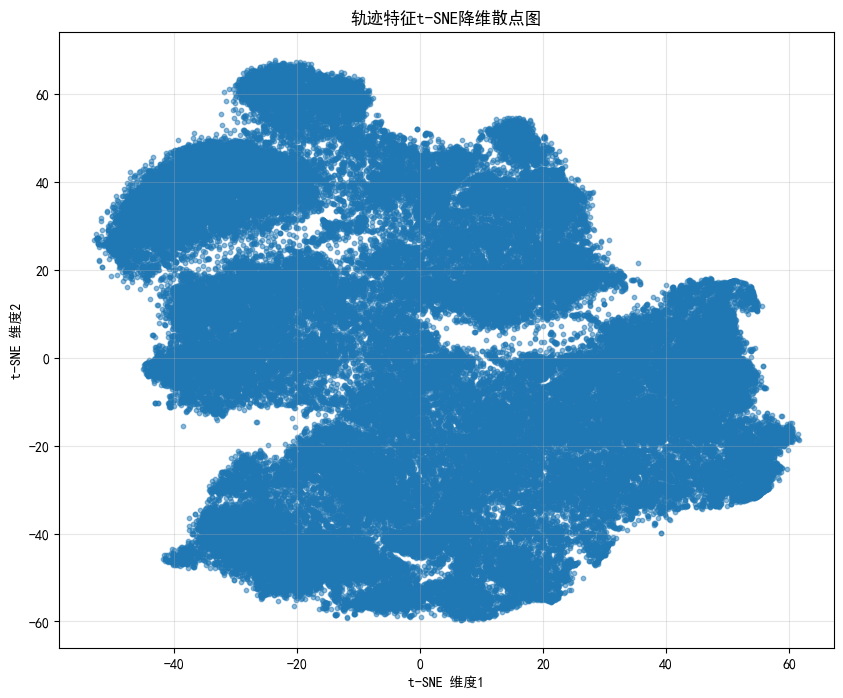

t-SNE可视化生成完成


In [13]:
from sklearn.manifold import TSNE

# t-SNE参数：perplexity设为样本数的平方根左右，适配数据规模
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=289,
    n_iter=1000,
    init='pca',
    learning_rate='auto'
)
tsne_result = tsne.fit_transform(feature_matrix)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, s=10)
plt.xlabel('t-SNE 维度1')
plt.ylabel('t-SNE 维度2')
plt.title('轨迹特征t-SNE降维散点图')
plt.grid(alpha=0.3)
plt.savefig('../results/figures/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("t-SNE可视化生成完成")